In [1]:
from qiskit.circuit import QuantumCircuit, QuantumRegister, AncillaRegister
from qiskit.quantum_info import Statevector, Operator
from qiskit import *

import matplotlib.pyplot as plt

import numpy as np

# QC II: Circuits and Algorithms, Grover search 

To summarize the content of Part I: Introduction/Foundations, we described the essence of quantum computing to be the matter of encoding information into 
quantum states and then manipulating quantum states according to what we understand about quantum dynamics, in order to process this information. In Part II, we will continue by exploring some interesting circuits, describe some of the novel features of quantum algorithms, and then describe Grover's search algorithm. Grover's search algorithm is one of the most important and well-known quantum algorithms. 

---------------------------------------------------------------

### Quantum parallelism and computing with superpositions

$$\renewcommand{\ket}[1]{|#1\rangle}$$
$$\renewcommand{\bra}[1]{\langle#1|}$$

In the last set of notes, we discussed some of the difference between classical information processing and quantum information processing. In the quantum formalism, 
we think of information as being carried by states of quantum systems, and states can be in superposition of other states. For qubit systems, we have distinguished computational basis states that encode classical bit strings. 

Many quantum algorithms often begin by creating a superposition of possible states of interest, before passing the state to some unitary gate $U_{f}$ -- which by linearity,
will result in a corresponding superposition of all possible outputs among the states involved with the original input superposition. So, there is a sense in which many functional applications are done "simutaneously", resulting in a superposition of results. 

Here is an illustration: suppose that we had some classical function $f$ that operates on classical bit strings. To keep things simple for now, suppose that $f: \mathbb{F}_{2}^{n} \rightarrow \mathbb{F}_{2}$ is a boolean function. Then, we consider an $(n+1)$-qubit system $\mathcal{H}(n+1)$ and a unitary operation

$$
U_{f}: \ket{ i_{0} \cdots i_{n-1} \mid i_{n} } \mapsto \ket{ i_{0} \cdots i_{n-1} \mid i_{n} \oplus f( i_{0} , \cdots i_{n-1}  ) }
$$

If we take the superposition of all states encoding length $n$-bitstrings with the first $n$ qubits, we get the state

$$
x = \frac{1}{\sqrt{2^{n}}} \Big(  \sum_{i_{0}, \cdots, i_{n-1}} \ket{ i_{0} \cdots i_{n-1} | 0 } \Big)
$$

Passing this through $U_{f}$ results in 


$$
U_{f}(x) = \frac{1}{\sqrt{2^{n}}} \Big(  \sum_{i_{0}, \cdots, i_{n-1}} \ket{ i_{0} \cdots i_{n-1} | f( i_{0}, \cdots, i_{n-1} ) } \Big)
$$


This resulting state is an equal superposition of all possible combinations of input/output values $( i_{0}, \cdots , i_{n-1} , f( i_{0} , \cdots , i_{n-1} ))$, which is not necessarily inherently a very meaningful state -- but depending on the task at hand, one can pass this through some gates that manipulate the probability amplitudes in one way or another. This is the general form of many quantum algorithms, as we will see.


---------------------------

$$\renewcommand{\ket}[1]{|#1\rangle}$$
$$\renewcommand{\bra}[1]{\langle#1|}$$
#### Deutch's algorithm 

We can illustrate the above idea in a simple but interesting example. While this is more of a novel "toy example", it is instructive and out-performs any classical algorithm.

<b> Deutch's problem: </b> Given a boolean function $f: \mathbb{F}_{2} \rightarrow \mathbb{F}_{2}$, determine if $f$ is a constant function. 


Any deterministic classical solution to this problem will require *two* calls of the function $f$ in order to determine if $f$ is constant. We will see that quantum parallelism will allow us to design a quantum circuit, with a corresponding quantum gate $U_{f}$, such that only a single application of $U_{f}$ will be required for 
us to deterministically conclude whether or not $f$ is constant. 

The gate $U_{f}$ here will be defined in the same way as we define above. In this context, $U_{f}: \mathcal{H}(2) \rightarrow \mathcal{H}(2)$ is a unitary transformation of a $2$-qubit system. It is defined by

$$
U_{f}: \ket{ i_{0} \mid i_{1} } \mapsto \ket{ i_{0} \mid i_{1} \oplus f(i_{0})}
$$


Deutch's algorithm proceeds as follows. 

1. First, we take the input ground state $\ket{00}$, and transform it to the state $\ket{\Phi^{+}} \ket{\Phi^{-}} = \frac{1}{2}( \ket{0} + \ket{1} ) ( \ket{0} - \ket{1} )$ 

2. We pass this state $\ket{+} \ket{-}$ through the gate $U_{f}$. We obtain

$$
U_{f} \big( \ket{+} \ket{-} \big) = U_{f} \big( \frac{1}{2}( \ket{0} + \ket{1} ) ( \ket{0} - \ket{1} ) \big) 
$$
$$
= \frac{1}{2} \Big(  \ket{ 0 \mid f(0) } + \ket{ 1 \mid f(1) } - \ket{0 \mid 1 \oplus f(0) } - \ket{ 1 \mid 1 \oplus f(1) } \Big)
$$

$$
= \frac{1}{2} \sum_{x = 0, 1 } \ket{x} \big( \ket{0 \oplus f(x) } - \ket{1 \oplus f(x) } \big) 
$$

$$
= \frac{1}{2} \sum_{x = 0, 1 } (-1)^{f(x)} \ket{x} \ket{-} 
$$

<u> If $f$ is constant </u> and $f(x) = 0$, then we see that the above resulting state will simply become 

$$\frac{1}{2} \Big( \ket{00} + \ket{10} - \ket{01} - \ket{11} \Big) = \ket{+} \ket{-}$$

If $f(x) = 1$, then the above resulting state will become 

$$\frac{1}{2} \Big( \ket{01} + \ket{11} - \ket{00} - \ket{10} \Big) = - \ket{+} \ket{-}$$

So, up to a global phase, the resulting state will be the same in the two cases where $f$ is a constant function. 


<u> If $f$ is not constant</u>, then we can easily check that the resulting state will always be $\ket{-}\ket{-}$, up to a global phase.


3. Therefore, the two scenarios (constant v.s. non-constant) will result in the state $\ket{+} \ket{-}$ or $\ket{-}\ket{-}$ respectively. After applying a Hadamard gate to the first of the two qubits, we will arrive at the state $\ket{0} \ket{-}$ or $\ket{1} \ket{-}$. The resulting state we get is completely determined by whether or not $f$ is constant. Therefore, by measuring the first qubit, we will get either $0$ or $1$; if the measurement result is $0$, then $f$ is constant, if the measurement result is $1$ then $f$ is non-constant. 


------------------------------


$$\renewcommand{\ket}[1]{|#1\rangle}$$
$$\renewcommand{\bra}[1]{\langle#1|}$$

## Grover's search algorithm

Grover's algorithm is a quantum algorithm that utilizes this quantum parallelism principle in order to search for items in an unstructured set of elements. 

Suppose that we have a set $S$ of $N$ elements, and we are searching for items $S^{*} = \{ x^{*}_{1}, \cdots, x^{*}_{M} \} \subset S$. We can formulate the search problem in a way that is aligned with the previous discussion above by considering a Boolean function $f: S \rightarrow \mathbb{F}_{2}$ such that $f(x) = 1$  iff $x \in S^{*}$. Then, as before, we will be considering the gate $U_{f}: \mathcal{H}(N+1) \rightarrow \mathcal{H}(N+1)$ which sends $\ket{ x , y }  \mapsto \ket{x , y \oplus f(x)}$. 

The idea here is that we encode the search space $S$ into computational basis elements of an $N$-qubit system. Then, we can take the equal superposition of all 
these encoded basis states 

$$
\ket{ u_{S} } = \frac{1}{\sqrt{2^{N}}} \big(  \sum_{ u_{i} \in S }  \ket{  x_{i}  }   \big)
$$


Then, we can apply $U_{f}$ to $\ket{ u_{S} } \ket{0}$:

$$
U \big( \ket{ u_{S} } \ket{0} \big) = \frac{1}{\sqrt{2^{N}}} \big(  \sum_{ x_{i} \in S }  \ket{  x_{i} \mid f( x_{i} )  }   \big)
$$


The above is an equal superposition of the encoded basis states, with the last qubit in state $\ket{1}$ iff $x_{i} \in S^{*}$, and in state $\ket{0}$ otherwise.
Grover's algorithm uses *amplitude amplification* in order to maximize the likelihood that when measuring the resulting state with respect to the computational basis, 
we will obtain the state some valid state $\ket{ x_{i} \mid 1 }$ of interest, with $x_{i} \in S^{*}$. 

Amplitude amplification here consists of applying a sequence of gates to the equal superposition $U \big( \ket{ u_{S} } \ket{0} \big)$ such that the probability amplitudes for the basis terms satisfying $f(x_{i}) = 1$ increase, while the probability amplitudes for the basis terms satisfying $f(x_{j}) = 0$ decrease. Recall that for a state-vector $\sum_{x} c_{x} \ket{x} $, we must have that $\sum_{x} |c_{x}|^{2} = 1$. So, we can really think of amplitude amplification in the direction of some basis state $\ket{x}$ as "rotating" a unit vector towards $\ket{x}$. 

To understand Grover's algorithm, we first note that the equal superposition statevector $\ket{u_{S}}$ can be written as

$$
\ket{u_{S}} = \sqrt{\frac{N - M}{N} } \ket{u_{S^{*}}^{\perp}} + \sqrt{\frac{M}{N}} \ket{ u_{S^{*}}}  
$$

This implies that $\ket{u_{S}}$ is contained in two dimensional subspace spanned by $\ket{u_{S^{*}}}$ and $\ket{u_{S^{*}}^{\perp}}$. 

<img src="grovercircle.png" style="display: block; margin: auto; width: 25%">


It is instructive to think of Grover's algorithm geometrically with the $\text{span}( \ket{u_{S^{*}}} , \ket{u_{S^{*}}^{\perp}} )$ unit circle as above. If the size of $M = |S^{*}|$ is small in comparision to $N$, then the equal superposition statevector $\ket{u_{S}}$ will be more skewed towards the $\ket{u_{S^{*}}}$ axis. Conversely, if the size of $M$ is large compared to $N$, then $\ket{u_{S}}$ will be skewed towards the $\ket{u_{S^{*}}}$ axis. Of course, we can easily see this algebraically as well. Recall that $\ket{u_{S}} = \sqrt{\frac{N - M}{N} } \ket{u_{S^{*}}^{\perp}} + \sqrt{\frac{M}{N}} \ket{ u_{S^{*}}}$, so the square-root ratio $\sqrt{ \frac{M}{N}}$ is precisely the coefficient of $\ket{u_{S^{*}}}$ in the linear combination.


Grover's algorithm essentially works by defining a unitary transformation $G$ that rotates statevectors by a particular fixed angle of rotation, with the hope that the angle and direction of rotation are so that if one applies $G$ enough times, $\ket{u_{S}}$ will be brought closer towards the $\ket{u_{S^{*}}}$ axis. If one is successful in doing this, we will have a statevector whose amplitude is more concentrated in the direction of $\ket{u_{S^{*}}}$. Upon measurement of the resulting statevector in the computational basis, we will then likely obtain a bitstring $x$ belonging to the marked set $S^{*}$ (where any specific bitstring in $S^{*}$ may occur equally likely). 


### Defining the angle of rotation (i.e. the Grover operator)


Recall that rotations can be defined by composing two hyperplane reflections. That is, if $\rho_{H}$ and $\rho_{H'}$ are reflections across hyperplanes $H$ and $H'$ respectively, then the composition $\rho_{H'} \circ \rho_{H}$ acts as a rotation by $\theta(H,H')$ degrees, where $\theta(H,H')$ is the angle formed by the hyperplanes $H$ and $H'$. 

The insight of Grover is that we should be looking at the angle between the equal superposition statevector $\ket{u_{S}}$ and the "bad axis" $\ket{u_{S^{*}}^{\perp}}$. If the marked elements $S^{*}$ are sufficiently sparse relative the $S$, then this angle will be quite small. Then, iterating rotations by this angle will rotate $\ket{u_{S}}$ in small steps towards $\ket{u_{S^{*}}}$. Note that if this angle is too large, we may "overshoot" and never reach a statevector close to $\ket{u_{S^{*}}}$ at all. 


The question that remains now, is if it is feasible to implement such a rotation with basic gates. As remarked above, this is a manner being able to implement hyperplane reflections with basic gates. First, let's look at how the reflection across the $\ket{u_{S}}$ axis can be implemented. 

Recall that we have the $Z$-gate

$$
Z_{0} = 
\begin{pmatrix}
-1 & 0 & \cdots & 0 \\
0  & 1 & \cdots & \cdots \\
0  & \cdots & \cdots & \cdots \\
0 & \cdots & \cdots  & 1
\end{pmatrix}
$$

which acts on a state vector $\ket{ i_{1} ,\cdots , i_{n}}$ by $Z_{0} \ket{ 0 }_{n} = -\ket{ 0} _{n}$, otherwise $Z_{0} \ket{ i_{1}, \cdots , i_{n}} = \ket{ i_{1}, \cdots , i_{n}}$. Then, as $H^{\otimes n} \ket{0}_{n} = \ket{u_{S}}$, it is easy to see that 


$$
Z_{u} := H^{\otimes n} \circ Z_{0} \circ H^{\otimes n} = 2 \ket{ u_{S} } \bra{ u_{S} } - \mathbb{I} 
$$

which is precisely the reflection across the $\ket{u_{S}}$ axis we were looking for. 


Defining the reflection across the $\ket{u_{S^{*}}^{\perp}}$ axis is a more delicate matter. As you might expect, there isn't going to be a universal way to define this reflection that will work for all instances of $S$ and $S^{*}$. The reflection is often referred to as the *Grover oracle*, which we will denote as $Z_{S^{*}}$. This is a unitary transformation that flips the sign of all of the "good states" marked by $S^{*}$. It is important to note that it does not require for us to know how to solve the search problem to implement this transformation, it's more that we can define a unitary transformation that flips the sign for any state in our encoded states that represents a marked element in $S^{*}$. That is, this is a matter of searching through an unstructured database, where we have fixed encodings for all of our bitstrings of interest, and we know how the marked bitstrings should be encoded. 

Given a search problem, you may have to work quite hard to think about how to implement $Z_{S^{*}}$ tailored to the context at hand. Thus, when speaking about Grover's algorithm in the abstract, $Z_{S^{*}}$ is often viewed as a *black box* operation -- with the understanding that $Z_{S^{*}}$ must be implemented before executing an instance of Grover's algorithm in practice. 

<!-- 
More specifically, the outline of the Grover algorithm is as follows:

1. Begin in the equal superposition state $\ket{u_{S}} \ket{0} $ as above. 

2. Apply the unitary transformation $U_{f}$ to $\ket{u_{S}} \ket{0}$, the resulting state is $\frac{1}{\sqrt{2^{N}}} \big(  \sum_{ x_{i} \in S }  \ket{  x_{i} \mid f( x_{i} )  }   \big)$.

3. Flip the sign for all basis vectors in the above superposition encoding items of interest. The resulting state will be 

$$
\frac{1}{\sqrt{2^{N}}} \big(  \sum_{ x_{i} \in S \setminus S^{*} }  \ket{  x_{i} \mid 0   } - \sum_{ u_{S} \in  S^{*} }  \ket{  u_{S} \mid 1  }    \big)
$$


4. Perform an *inversion about the average* transformation. We write $A$ for the average of the amplitudes of the current state. This inversion transformation 
acts on states as:
$$c_{x}\ket{x}   \mapsto ( 2A - c_{x} ) \ket{x}$$


The main claim here is that the resulting state of the system after applying these steps has the property that the probability amplitudes $|c_{x}|^{2}$ become larger if $x \in S^{*}$ and become smaller if $x \notin S^{*}$.   


One can easily see that the "inversion about the average" operation can be realized via the following unitary matrix

$$
D = 
\begin{pmatrix} 
\frac{2}{N} - 1 & \frac{2}{N} & \cdots & \frac{2}{N} \\
\frac{2}{N} & \frac{2}{N} - 1 & \cdots & \frac{2}{N} \\
\cdots & \cdots & \cdots &  \cdots  \\
\cdots & \cdots & \cdots & \frac{2}{N} - 1 \\
\end{pmatrix}
$$

At least this will convince us that inversion about the average is indeed a unitary transformation. However, to implement Grover's algorithm with a quantum circuit, we would like to build this transformation with some basic unitary gates.

Following Grover's original paper (1996), the key insight is that the inversion about the average matrix $D$ above there can be realized as the following

$$
D = - H^{\otimes n} \circ Z_{0} \circ H^{\otimes n} 
$$

where $H^{\otimes n} = H \otimes H \otimes \cdots \otimes H$ is the Walsh-Hadamard transformation, and $Z_{0}$ is defined by reflection across the orthogonal hyperplane to $\ket{0}^{\otimes n}$. That is,

$$
Z_{0} = 
\begin{pmatrix}
-1 & 0 & \cdots & 0 \\
0  & 1 & \cdots & \cdots \\
0  & \cdots & \cdots & \cdots \\
0 & \cdots & \cdots  & 1
\end{pmatrix}
$$

Step $3$ in the listed steps above is sometimes referred to the *Grover oracle marker* step. One calls the operation $Z_{S^{*}}$ the "marker oracle", the unitary that flips the sign of all of the "good states" marked by $S^{*}$. Unlike the inversion about the average matrix $D$, there isn't necessarily a prescribed way to write $Z_{S^{*}}$ down as a practical unitary transformation. Given a search problem, you may have to work quite hard to think about how to implement $Z_{S^{*}}$ tailored to the context at hand. Thus, when speaking about Grover's algorithm in the abstract, $Z_{S^{*}}$ is often viewed as a *black box* operation -- with the understanding that $Z_{S^{*}}$ must be implemented before executing an instance of Grover's algorithm in practice. 

Then, steps $1$ to $4$ above can be summarized by the application of the following operator, called the *Grover iterator* -->

To summarize, Grover's algorithm works by iterating the *Grover operator*

$$
G = Z_{u} \circ Z_{S^{*}} = - H^{\otimes n} \circ Z_{0} \circ H^{\otimes n} \circ Z_{S^{*}}
$$

which acts as a rotation by the angle between $\ket{u_{S}}$ and $\ket{u_{S^{*}}^{\perp}}$.



### Analysis of the Grover operator


Let us consider the action of the Grover iterator $G$ on $\ket{u_{S^{*}}}$ and $\ket{u_{S^{*}}^{\perp}}$. We have:


$$
G \ket{u_{S^{*}}^{\perp}} = ( \frac{2(N - M) }{N} - 1 ) \ket{u_{S^{*}}^{\perp}} + 2 \frac{ \sqrt{ N \cdot M } } {N} \ket{ u_{S^{*}}} 
$$



$$
G \ket{u_{S^{*}}} = - 2 \frac{ \sqrt{ N \cdot M } }{N} \ket{u_{S^{*}}^{\perp}} + ( \frac{2(N - M) }{N} - 1 )  \ket{ u_{S^{*}} } 
$$

Therefore, if we consider $G$ as an operator acting on the $2$-dimensional subspace spanned by $\ket{u_{S^{*}}}$ and $\ket{u_{S^{*}}^{\perp}}$, then we can represent $G$ with the matrix

$$
G = 
\begin{pmatrix}
 \frac{N - 2M }{N}   &   2 \frac{ \sqrt{ N \cdot M } } {N}   \\
 - 2 \frac{ \sqrt{ N \cdot M } } {N}   &  \frac{N - 2M }{N} 
\end{pmatrix}
$$

In fact, one can easily check that if we set

$$
\sqrt{G} :=
\begin{pmatrix}
\sqrt{ \frac{ N - M }{N} } & -\sqrt{\frac{M}{N} } \\
\sqrt{\frac{ M }{N} } & \sqrt{ \frac{ N - M  }{N} }
\end{pmatrix}
$$

then, we have that

$$
(\sqrt{G})^{2} = \begin{pmatrix}
\sqrt{ \frac{ N - M }{N} } & -\sqrt{\frac{M}{N} } \\
\sqrt{\frac{ M }{N} } & \sqrt{ \frac{ N - M  }{N} }
\end{pmatrix}^{2} = \begin{pmatrix}
\sqrt{ \frac{ N - M }{N} } & -\sqrt{\frac{M}{N} } \\
\sqrt{\frac{ M }{N} } & \sqrt{ \frac{ N - M  }{N} }
\end{pmatrix} = G
$$

Furthermore, it is easy to see that $\det( \sqrt{G} ) = 1$, so that $\sqrt{G}$ and $G$ are rotation matrices. More specifically, we see that by choosing $\theta = \arcsin{\sqrt{ M / N  } }$, one has that 

$$
\begin{pmatrix}
\sqrt{ \frac{ N - M  }{N} } & \sqrt{\frac{M}{N} } \\
-\sqrt{\frac{M}{N} } & \sqrt{ \frac{ N - M }{N} }
\end{pmatrix}
$$
$$
=
\begin{pmatrix}
\cos(\theta) & -\sin(\theta) \\
\sin(\theta) & \cos(\theta)
\end{pmatrix}
$$
and that 

$$
G =  \begin{pmatrix}
 \frac{N - 2M }{N}   &   2 \frac{ \sqrt{ N \cdot M } } {N}   \\
 - 2 \frac{ \sqrt{ N \cdot M } } {N}   &  \frac{N - 2M }{N} 
\end{pmatrix}
= \begin{pmatrix}
\cos(2 \theta) & -\sin(2 \theta) \\
\sin(2 \theta) & \cos( 2 \theta)
\end{pmatrix}
$$


So, this is the explicit form of the Grover operator as a rotation matrix.


Note that we can also write 

$$
\theta = \arccos( \sqrt{ \frac{N - M }{N} } )
$$

So that our equally uniform superposition state $\ket{u_{S}}$ can be written:

$$
\ket{u_{S}} = \sqrt{ \frac{N - M } {N} } \ket{ u_{S^{*}}^{\perp} } + \sqrt{ \frac{ M }{N}} \ket{ u_{S^{*}}}  = \cos(\theta) \ket{ u_{S^{*}}^{\perp} } + \sin(\theta) \ket{ u_{S^{*}} } 
$$

Then, the above identity says that 
$$
G \ket{u_{S}} = \cos( 3\theta ) \ket{u_{S^{*}}^{\perp}} + \sin( 3 \theta ) \ket{ u_{S^{*}}}
$$

so that 
$$
G^{t} \ket{u_{S}}  =  \cos( (2t + 1) \theta) \ket{ u_{S^{*}}^{\perp} } +  \sin( (2t + 1 )\theta ) \ket{ u_{S^{*}}}
$$

<!-- 
Therefore, depending on the angle $\theta$, the idea behind Grover's algorithm is to take enough iterations of $G$, acting on $\ket{u_{S}}$, with the hope that there is a 
number of iterations so that the resulting state "concentrates its amplitude" in the direction of the vector $\ket{u_{S^{*}}}$.  -->

If $\theta = \arcsin(\sqrt{ \frac{ M }{N} })$ is sufficiently small (equivalently, if $M = |S^{*}|$ is sufficiently small compared to $N$), then choosing $t$ to be the nearest integer to $\frac{\pi}{2 \theta}$ gives us 

$$
| (2t+1) \cdot \theta - \frac{\pi}{2} | \leq \theta
$$

which is small, provided that $\theta$ is small. Then, $\sin( (2t+1)\theta)$ will be reasonably close to $1$. Of course, it is unlikely that $\sin( (2t+1) \theta)$ will actually be $1$ (only possible if $|S^{*}| = N$), measuring $\ket{u_{S}}$ in the basis $\{ \ket{ u_{S^{*}} } , \ket{ u_{S^{*}}^{\perp} } \}$ around $1 / \sin( (2t+1) \theta)$ many times should result in an element $s^{*} \in S^{*}$. If $\sin( (2t+1) \theta)$ is close to $1$, then this probability will be close to $1$.  

Perhaps it is clear from the presentation of Grover's algorithm, by no means is it guaranteed that iterating the Grover iterator operator over and over again will necessarily improve the amplitude towards the $\ket{u_{S^{*}}}$ direction. In fact, even in the ideal situation where we can actually iterate $G$ some integer $T$ number of times to get $\sin ( (2T  +1 ) \theta )$  close to $1$, iterating $G$ further to $t > T$ may actually make this amplitude go down ( "over-cooking").

#### The ideal number of Grover iterations

  In our above discussion, we saw that the point is to bring $\sin( (2t+1) \theta)$ as close to $1$ as possible. This occurs when $t = \frac{\pi}{4} \frac{1}{\theta} - \frac{1}{2}$, so we can take the nearest integer to $\frac{\pi}{4} \frac{1}{\theta} - \frac{1}{2}$ as the ideal number of iterations. This is also the same as taking the floor of $\frac{\pi}{4} \frac{1}{\theta}$. If $\theta$ is sufficiently small, then using this choice of $t$ should give a reasonably good probability for measuring $\ket{u_{S}}$ in $\ket{u_{S^{*}}}, \ket{ u_{S^{*}}^{\perp}}$ and getting $\ket{u_{S^{*}}}$. 


> Example: If $|S^{*}| = \frac{1}{4} N$, then the optimal number of iterations is $1$. If $|S^{*}| = \frac{1}{2} N$, then no number of iterations of $G$ will improve the situation.  

Here is an interactive illustration of how the Grover iterations look like, depending on the relative size of $S^{*}$ compared to $N$. 

[Grover reflection applet](applets/grover-reflections.html)


-------------------------------------------------------------------------------


$$\renewcommand{\ket}[1]{|#1\rangle}$$
$$\renewcommand{\bra}[1]{\langle#1|}$$
### Grover's algorithm in action



 


#### <u> Example 0: small sanity check example </u>


Let's take an explicit look at Grover's algorithm for a small example. Here, we will search through a set of $4$ bit strings S = { '00', '01','10','11' }. Of course, "searching" through this set for a particular set sounds like a silly idea -- so if you wish, we can frame this instead in terms of using Grover's algorithm to amplify the amplitude of a particular basis element in the computational basis of $\mathcal{H}(2)$. Let us choose to amplify the amplitude of $\ket{11}$. So, in the language above, we have that $S^{*} =$ { '11' } is a singleton set, and we have that $|S^{*}| = \frac{1}{4} \cdot 4  = 1$. Thus, a single iteration of the Grover iterator should bring the input state optimally close to $\ket{11}$. 


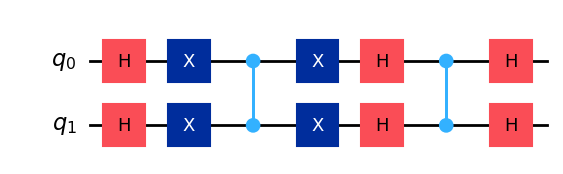

In [2]:
qc = QuantumCircuit(2)


qc.h(qc.qubits  )

qc.x( qc.qubits )
qc.cz(1,0)
qc.x( qc.qubits )


qc.h(qc.qubits  )
qc.cz(1,0)
qc.h(qc.qubits )


qc.draw('mpl') 


In [3]:
statevector = Statevector(qc)

statevector.draw('Latex')

<IPython.core.display.Latex object>

$$\renewcommand{\ket}[1]{|#1\rangle}$$
$$\renewcommand{\bra}[1]{\langle#1|}$$
After applying $H^{\otimes 2}$ to $\ket{00}$, we have the uniform superposition state vector $\frac{1}{2} \Big( \ket{00} + \ket{01} + \ket{10} + \ket{11} \Big) = \ket{u_{S}}$.  Measuring this with respect to the computational basis will give us $\ket{11}$ with probability $\frac{1}{4}$. After applying a single Grover iteration, we arrive at the state $\ket{11}$ -- so measuring this with respect to the computational basis gives the outcome $\ket{11}$ with certainty. 


As mentioned before, the example above is a little silly: we knew ahead of time that $\ket{11}$ was the only thing we were looking for, so defining the "oracle circuit" $Z_{S^{*}}$ in this situation was a triviality. This was not really an example of a search problem in action, but more of an example of selective amplitude amplification. Let us consider some examples where the solution set $S^{*}$ is not as obvious to us, so we do not use answer to the search problem in defining the oracle circuit. 


$$\renewcommand{\ket}[1]{|#1\rangle}$$
$$\renewcommand{\bra}[1]{\langle#1|}$$
#### <u> Example 1: solving pseudo-boolean equations </u>

Let $F: \mathbb{F}_{2}^{2} \rightarrow \mathbb{Z}$ be defined by

$$
F(x_{0}, x_{1} ) = 2 x_{0} + x_{1}
$$

Let's use Grover's algorithm to find solutions to the equation

$$
F(x_{0}, x_{1} ) = 2
$$

To define the oracle marker circuit, note that $F$ above outputs the decimal representation of a binary number defined by the sequence $x_{0} , x_{1}$ (in "big Endian notation"). We will make use of *ancilla qubits*. 

> Ancilla qubits: ancilla qubits are extra qubits we introduce to our system, to help us with processing our quantum states. They often act as temporary registers 
> that can for example hold some kind of temporary "memory". If some information about a state in the original register of qubits can be encoded by some numerical 
> representation, we can conditionally set the state of the ancilla qubits to a state corresponding to the binary representation of this information (conditioned on the state of input register). 

$$\renewcommand{\ket}[1]{|#1\rangle}$$
$$\renewcommand{\bra}[1]{\langle#1|}$$
In the below example, we use two ancilla qubits $\ket{y_{1} y_{0}}$. The circuit below will change the state $\ket{y_{1} y_{0}}$ to the $2$-digit binary number representing $y_{1} y_{0} + F(x_{0}, x_{1})_{2}$, where $F(x_{0}, x_{1})_{2}$ is the binary representation of $F(x_{0}, x_{1}) \in \mathbb{Z}$. Therefore, if the ancillia qubits begin in the state $\ket{00}$, then passing $\ket{ x_{0} x_{1} \mid 0 0 }$ through the circuit will result in the output state $\ket{ x_{0} x_{1} \mid F(x_{0}, x_{1})_{2} }$.


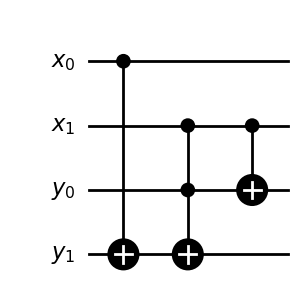

In [4]:
quantum_register = QuantumRegister(size=2, name="x")
ancilla_register = AncillaRegister(size=2, name="y")

F_adder = QuantumCircuit(quantum_register, ancilla_register, name="F(x) adder")

F_adder.cx(quantum_register[0], ancilla_register[1])
F_adder.ccx(quantum_register[1], ancilla_register[0], ancilla_register[1])
F_adder.cx(quantum_register[1], ancilla_register[0])

F_adder.draw(output="mpl", style="bw")

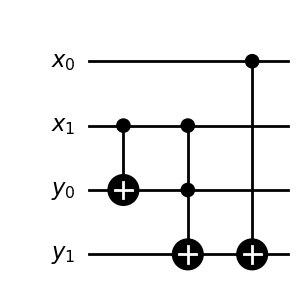

In [5]:
quantum_register = QuantumRegister(size=2, name="x")
ancilla_register = AncillaRegister(size=2, name="y")

F_subtractor = QuantumCircuit(quantum_register, ancilla_register, name="F(x) subtractor")



F_subtractor.cx(quantum_register[1], ancilla_register[0])
F_subtractor.ccx(quantum_register[1], ancilla_register[0], ancilla_register[1])
F_subtractor.cx(quantum_register[0], ancilla_register[1])
    
F_subtractor.draw(output="mpl", style="bw")

In [6]:
A = F_adder.to_gate()
Adg = F_subtractor.to_gate()

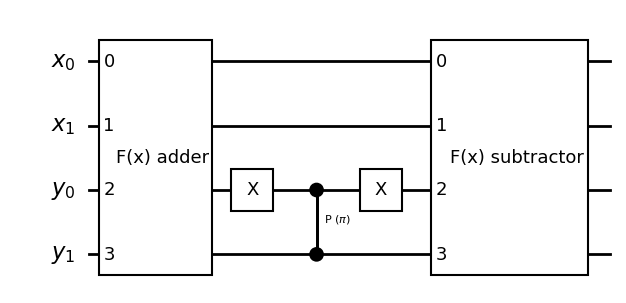

In [7]:
quantum_register = QuantumRegister(size=2, name="x")
ancilla_register = AncillaRegister(size=2, name="y")

marker_circuit = QuantumCircuit(quantum_register, ancilla_register, name="marker")


marker_circuit.compose(A, inplace=True)
marker_circuit.x(ancilla_register[0])
marker_circuit.cp(np.pi, ancilla_register[0], ancilla_register[1])
marker_circuit.x(ancilla_register[0])
marker_circuit.compose(Adg, inplace=True)





###

marker_circuit.draw(output="mpl", style="bw")

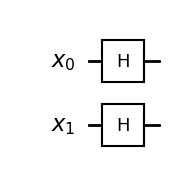

In [8]:
quantum_register = QuantumRegister(size=2, name="x")

state_preparation_circuit = QuantumCircuit(quantum_register, name="State preparation")

state_preparation_circuit.h(quantum_register)

state_preparation_circuit.draw(output="mpl", style="bw")

In [9]:
Prep = state_preparation_circuit.to_gate()

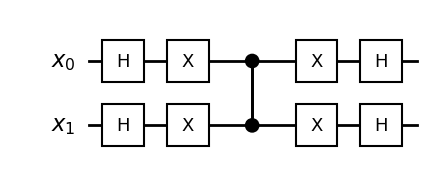

In [10]:
quantum_register = QuantumRegister(size=2, name="x")

diffuser_circuit = QuantumCircuit(quantum_register, name="diffuser")

diffuser_circuit.h(quantum_register)
diffuser_circuit.x(quantum_register)
diffuser_circuit.cz(quantum_register[0], quantum_register[1])
diffuser_circuit.x(quantum_register)
diffuser_circuit.h(quantum_register)




###

diffuser_circuit.draw(output="mpl", style="bw")

In [11]:
U = marker_circuit.to_gate()
D = diffuser_circuit.to_gate()

In [12]:
n = 2
N = 2**n
K =int(np.rint(np.pi / (4 * np.arcsin(1 / np.sqrt(N))) - 1/2))

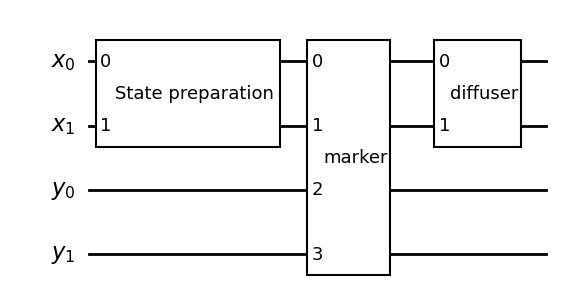

In [13]:
quantum_register = QuantumRegister(size=2, name="x")
ancilla_register = AncillaRegister(size=2, name="y")

grover_circuit = QuantumCircuit(quantum_register, ancilla_register, name="Grover circuit")

grover_circuit.compose(Prep, inplace=True)  

for i in range(K):
    grover_circuit.compose(U, inplace=True)
    grover_circuit.compose(D, inplace=True) 



###

grover_circuit.draw(output="mpl", style="bw")

In [14]:
psi = Statevector(grover_circuit)
psi.probabilities()

array([1.02806040e-33, 1.00000000e+00, 9.37349864e-34, 1.49505588e-33,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00])

In [15]:
np.round(psi.probabilities(), 4)


array([0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])

In [16]:
psi.draw('Latex')

<IPython.core.display.Latex object>

In [17]:
n = 7
N = 2**n
K = int(np.rint(np.pi / (4 * np.arcsin(1 / np.sqrt(N))) - 1/2))
Theta = 2 * np.arcsin(1/np.sqrt(N))
K, Theta

(8, np.float64(0.1770076862880309))

In [18]:
iterations = np.arange(1, 4 * K + 1) # let us allow under-, and overcooking
P_success_over_time = np.square(np.sin((iterations + 1/2) * Theta))

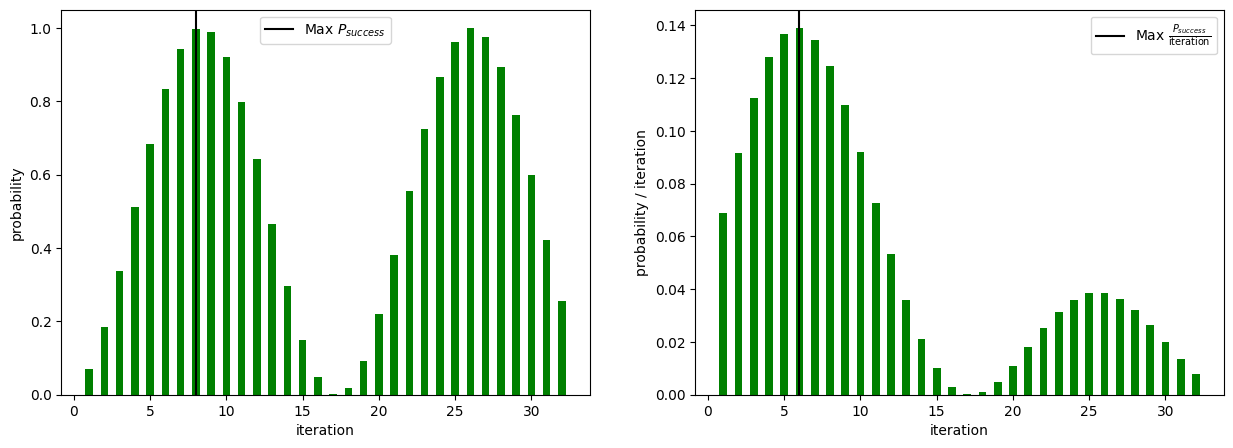

In [19]:
fig, axs = plt.subplots(nrows=1, ncols=2, sharey=False, figsize=(15, 5))

axs[0].bar(iterations,
           P_success_over_time,
           width=0.5,
           color="green")
axs[0].set(xlabel=f"iteration",
           ylabel=f"probability")
axs[0].axvline(x = K,
               linewidth=1.5,
               color="black",
               label=r"Max $P_{success}$")

axs[0].legend(loc='best')

axs[1].bar(iterations,
           P_success_over_time / iterations,
           width=0.5,
           color="green")
axs[1].set(xlabel=f"iteration",
           ylabel=f"probability / iteration")
axs[1].axvline(x = iterations[np.argmax(P_success_over_time / iterations)],
               linewidth=1.5,
               color="black",
               label=r"Max $\frac{P_{success}}{\mathrm{iteration}}$")

axs[1].legend(loc='best')

plt.show()

#### <u> Example 2: Dependency on relative sizes of solution versus input space </u>

 In this example, we are looking for 4 bits $x_{0}, x_{1}, x_{2}, x_{3}$
such that 

\begin{equation} 
x_{0} \wedge x_{1}  \equiv x_{2} \oplus x_{3}
\end{equation}


$$\renewcommand{\ket}[1]{|#1\rangle}$$
$$\renewcommand{\bra}[1]{\langle#1|}$$
To implement the oracle required for this search problem, we first construct a circuit that implements 

\begin{equation*}
| x_{0}, x_{1}, x_{2}, x_{3} \rangle | 0 \rangle \mapsto | x_{0}, x_{1} , x_{2} \rangle  | x_{2} \oplus x_{3}  \rangle  |  ( x_{0} \wedge x_{1} ) \oplus ( x_{2} \oplus x_{3} ) \rangle
\end{equation*} 

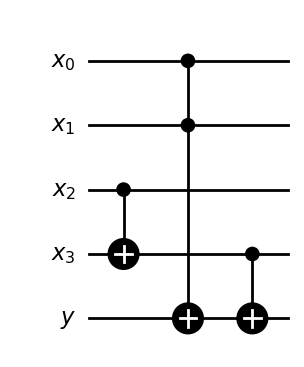

In [20]:
quantum_register = QuantumRegister(size=4, name="x")
ancilla_register = AncillaRegister(size=1, name="y")

SAT = QuantumCircuit(quantum_register, ancilla_register, name="sat")

SAT.cx(quantum_register[2], quantum_register[3])
## SAT.cx(quantum_register[3], ancilla_register[1]) 
SAT.ccx(quantum_register[0], quantum_register[1], ancilla_register[0])
SAT.cx(quantum_register[3], ancilla_register[0])


SAT.draw(output='mpl',  style="bw")


We will also need to consider the inverse circuit:

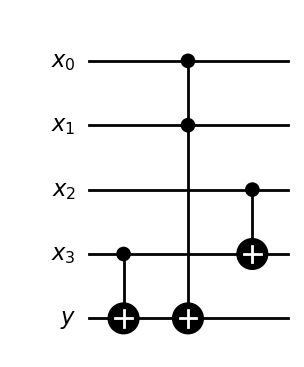

In [21]:
SAT.inverse().draw(output="mpl", style="bw")

In [22]:
A = SAT.to_gate(label="SAT")
Adg = SAT.inverse().to_gate(label="SAT inverse")


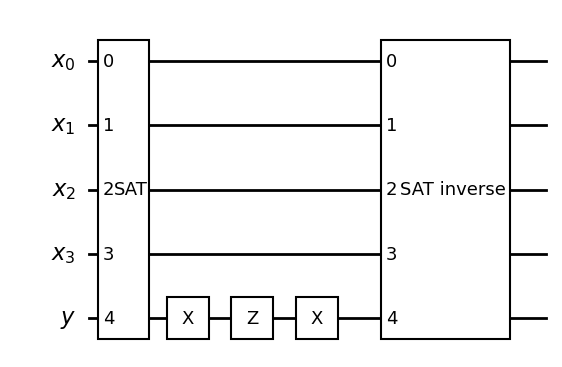

In [23]:
quantum_register = QuantumRegister(size=4, name="x")
ancilla_register = AncillaRegister(size=1, name="y")

marker_circuit = QuantumCircuit(quantum_register, ancilla_register, name="marker")


marker_circuit.compose(A, inplace=True)

marker_circuit.x(ancilla_register[0])
marker_circuit.z(ancilla_register[0])
marker_circuit.x(ancilla_register[0])


marker_circuit.compose(Adg, inplace=True)





###

marker_circuit.draw(output="mpl", style="bw")

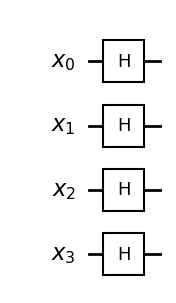

In [24]:
quantum_register = QuantumRegister(size=4, name="x")

state_preparation_circuit = QuantumCircuit(quantum_register, name="State preparation")

state_preparation_circuit.h(quantum_register)

state_preparation_circuit.draw(output="mpl", style="bw")

In [25]:
Prep = state_preparation_circuit.to_gate()

C:\Users\Asus\AppData\Local\Temp\ipykernel_9124\1465151339.py:11: DeprecationWarning: The class ``qiskit.circuit.library.generalized_gates.mcmt.MCMT`` is deprecated as of Qiskit 1.4. It will be removed no earlier than 3 months after the release date. Use MCMTGate instead.
  diffuser_circuit.compose(MCMT(ZGate(), 3, 1), inplace=True)


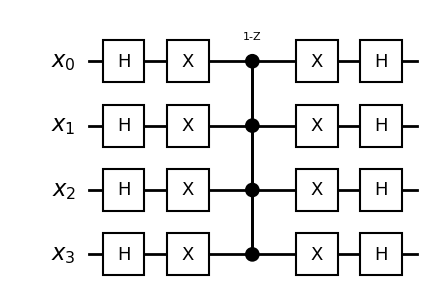

In [26]:
from qiskit.circuit.library import MCMT, ZGate


quantum_register = QuantumRegister(size=4, name="x")

diffuser_circuit = QuantumCircuit(quantum_register, name="diffuser")

diffuser_circuit.h(quantum_register)
diffuser_circuit.x(quantum_register)

diffuser_circuit.compose(MCMT(ZGate(), 3, 1), inplace=True)
## diffuser_circuit.compose(MCMT('z', 3, 1), inplace=True)
diffuser_circuit.x(quantum_register)
diffuser_circuit.h(quantum_register)




###

diffuser_circuit.draw(output="mpl", style="bw")

In [27]:
U = marker_circuit.to_gate()
D = diffuser_circuit.to_gate()

In [28]:

n = 4
N = 2**n
print(N)
M = 8  # number of marked elements.. initial guess is 8

K =  int( np.rint(np.pi / (4 * np.arcsin(np.sqrt(M) / np.sqrt(N))) - 1/2)  )




16


There are $2^{4} = 16$ possible input strings $(x_{0},x_{1},x_{2},x_{4})$, and there should be $8$ solutions..
Therefore, the number of solutions is exactly half the number of possible input strings.. In this case, Grover's algorithm will not work very well. 

According to the formula for the optimal number of iterations.. K = 0, so we don't run the Grover operator even once in this situation.

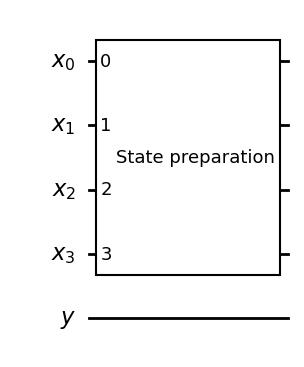

In [29]:

def create_grover(n, K):
    """
    """
    quantum_register = QuantumRegister(size=n, name="x")
    ancilla_register = AncillaRegister(size=1, name="y")

    grover_circuit = QuantumCircuit(quantum_register, ancilla_register, name="Grover circuit")

    grover_circuit.compose(Prep, inplace=True)  

    K =  int( np.rint(np.pi / (4 * np.arcsin(np.sqrt(M) / np.sqrt(2**n))) - 1/2)  )

    for i in range(K):
        grover_circuit.compose(U, inplace=True)
        grover_circuit.compose(D, inplace=True) 

    return grover_circuit
###
grover_circuit = create_grover(4, K)
grover_circuit.draw(output="mpl", style="bw")

In this case, we pick a string at random and see if the string is a solution. There is no amplitude amplification happening here.

In [30]:
psi = Statevector(grover_circuit)


In [31]:
psi.draw("Latex")

<IPython.core.display.Latex object>

In [32]:
np.round(psi.probabilities(), 4)


array([0.0625, 0.0625, 0.0625, 0.0625, 0.0625, 0.0625, 0.0625, 0.0625,
       0.0625, 0.0625, 0.0625, 0.0625, 0.0625, 0.0625, 0.0625, 0.0625,
       0.    , 0.    , 0.    , 0.    , 0.    , 0.    , 0.    , 0.    ,
       0.    , 0.    , 0.    , 0.    , 0.    , 0.    , 0.    , 0.    ])

In [33]:
def SATcheck(s):
    """
    Check if the given string s is a solution to the SAT problem.
    """
    # Convert the string to a list of integers
    s = [int(x) for x in s]
    # Check if the clauses are satisfied
    LHS = (int(s[0]) + int(s[1])) % 2
    RHS = (int(s[2]) * int(s[3])) % 2
    return  LHS == RHS


In [34]:
good = 0 
for i in range(100):
    psi = Statevector(grover_circuit)
    teststring = psi.measure()[0][-4:]
    #print(teststring)
    if SATcheck(teststring):
        #print("SAT")
        good += 1

#
print("success rate:" + str(good) + "%")     

success rate:54%


We can try again with a different number of iterations.. 


In [35]:
K = 3
grover_circuit = create_grover(4, K)

good = 0 
for i in range(100):
    psi = Statevector(grover_circuit)
    teststring = psi.measure()[0][-4:]
    #print(teststring)
    if SATcheck(teststring):
        #print("SAT")
        good += 1

#
print("success rate:" + str(good) + "%")    

success rate:53%


$$\renewcommand{\ket}[1]{|#1\rangle}$$
$$\renewcommand{\bra}[1]{\langle#1|}$$
What we can do is double the size of the search space, where there are no new solutions among the additional strings. Now, we will work with 5 qubits..
 
 Now, we define a circuit that implements:

\begin{equation*}
| x_{0}, x_{1}, x_{2}, x_{3} , x_{4} \rangle | 0 \rangle | 0 \rangle \mapsto | x_{0}, x_{1} , x_{2}, x_{4} \rangle \rangle  | x_{2} \oplus x_{3}  \rangle  |  ( x_{0} \wedge x_{1} ) \oplus ( x_{2} \oplus x_{3} ) \rangle  | \neg \big( (x_{2} \oplus x_{3}  ) \equiv  x_{0} \wedge x_{1} ) \big) \wedge \neg x_{4} \rangle 
\end{equation*}


This will allow us to implement a similar marker oracle as before, but now the equation

\begin{equation*}
\neg \big( (x_{2} \oplus x_{3}  ) \equiv  x_{0} \wedge x_{1} ) \big) \wedge \neg x_{4}
\end{equation*}

will only result in $1$ iff 

\begin{align*}
& \big( (x_{2} \oplus x_{3}  ) \equiv  x_{0} \wedge x_{1} ) \big) = 0 \\
& x_{4} = 0
\end{align*}


So that $(x_{0},x_{1},x_{2},x_{3},x_{4})$ is a solution if and only if $x_{4} = 0$ and $(x_{0}, x_{1}, x_{2}, x_{3})$ is a solution to 

\begin{equation*}
 (x_{2} \oplus x_{3}  ) \equiv  x_{0} \wedge x_{1} 
\end{equation*}


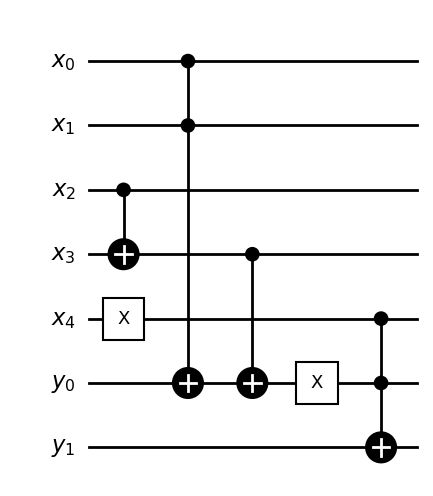

In [36]:
quantum_register = QuantumRegister(size=5, name="x")
ancilla_register = AncillaRegister(size=2, name="y")

SAT_new = QuantumCircuit(quantum_register, ancilla_register, name="new sat")

SAT_new.cx(quantum_register[2], quantum_register[3])
## SAT.cx(quantum_register[3], ancilla_register[1]) 
SAT_new.ccx(quantum_register[0], quantum_register[1], ancilla_register[0])
SAT_new.cx(quantum_register[3], ancilla_register[0])
SAT_new.x(quantum_register[4])
SAT_new.x(ancilla_register[0])
SAT_new.ccx(ancilla_register[0], quantum_register[4], ancilla_register[1])

SAT_new.draw(output='mpl',  style="bw")


In [37]:
Anew = SAT_new.to_gate(label="newSAT")
Anewdg = SAT_new.inverse().to_gate(label="newSAT inverse")

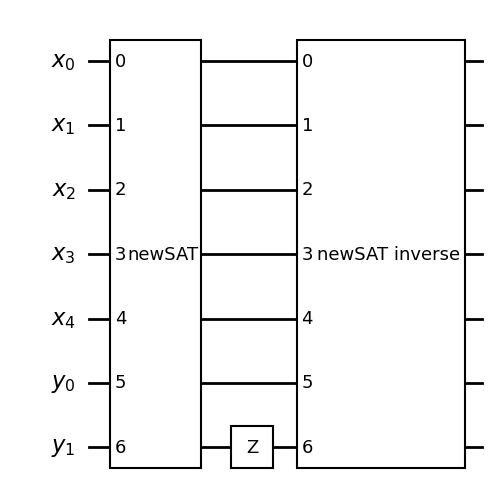

In [38]:
quantum_register = QuantumRegister(size=5, name="x")
ancilla_register = AncillaRegister(size=2, name="y")

marker_circuit = QuantumCircuit(quantum_register, ancilla_register, name="marker")


marker_circuit.compose(Anew, inplace=True)

marker_circuit.z(ancilla_register[1])


marker_circuit.compose(Anewdg, inplace=True)





###

marker_circuit.draw(output="mpl", style="bw")

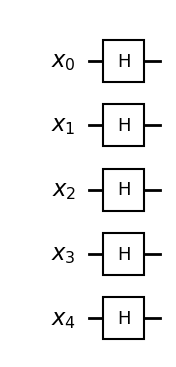

In [39]:
quantum_register = QuantumRegister(size=5, name="x")

state_preparation_circuit = QuantumCircuit(quantum_register, name="State preparation")

state_preparation_circuit.h(quantum_register)

state_preparation_circuit.draw(output="mpl", style="bw")

C:\Users\Asus\AppData\Local\Temp\ipykernel_9124\4202451381.py:8: DeprecationWarning: The class ``qiskit.circuit.library.generalized_gates.mcmt.MCMT`` is deprecated as of Qiskit 1.4. It will be removed no earlier than 3 months after the release date. Use MCMTGate instead.
  diffuser_circuit.compose(MCMT(ZGate(), 4, 1), inplace=True)


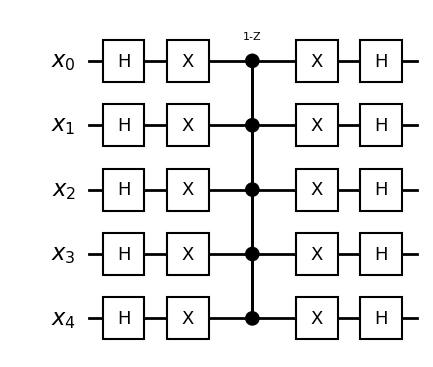

In [40]:

quantum_register = QuantumRegister(size=5, name="x")

diffuser_circuit = QuantumCircuit(quantum_register, name="diffuser")

diffuser_circuit.h(quantum_register)
diffuser_circuit.x(quantum_register)

diffuser_circuit.compose(MCMT(ZGate(), 4, 1), inplace=True)
## diffuser_circuit.compose(MCMT('z', 3, 1), inplace=True)
diffuser_circuit.x(quantum_register)
diffuser_circuit.h(quantum_register)




###

diffuser_circuit.draw(output="mpl", style="bw")

In [41]:
Prep_new = state_preparation_circuit.to_gate()
U_new = marker_circuit.to_gate()
D_new = diffuser_circuit.to_gate()

In [42]:
n = 5
N = 2**n
#print(N)
M = 8  # number of marked elements.. initial guess is 8

K =  int( np.rint(np.pi / (4 * np.arcsin(np.sqrt(M) / np.sqrt(N))) - 1/2)  )
print(K)

1


In contrast to the situation before, now the optimal number of iterations is 1, and not 0

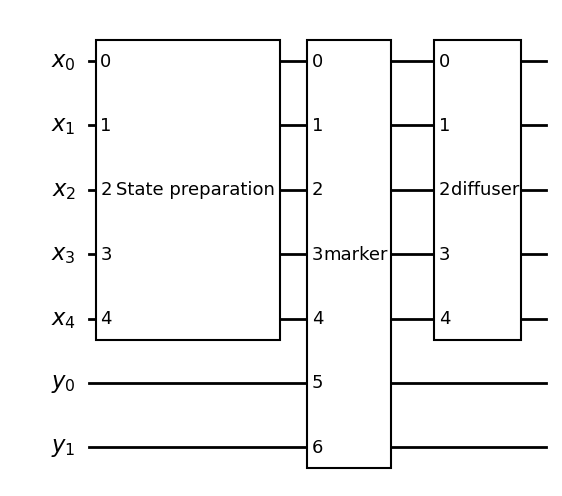

In [43]:
quantum_register = QuantumRegister(size=5, name="x")
ancilla_register = AncillaRegister(size=2, name="y")



grover_circuit = QuantumCircuit(quantum_register, ancilla_register, name="Grover circuit")

grover_circuit.compose(Prep_new, inplace=True)  

for i in range(K):
    grover_circuit.compose(U_new, inplace=True)
    grover_circuit.compose(D_new, inplace=True)  
    
    
grover_circuit.draw(output="mpl", style="bw")

In [44]:
psi = Statevector(grover_circuit)
psi.probabilities()
np.round(psi.probabilities(), 4)

array([0.125, 0.125, 0.125, 0.   , 0.   , 0.   , 0.   , 0.125, 0.   ,
       0.   , 0.   , 0.125, 0.125, 0.125, 0.125, 0.   , 0.   , 0.   ,
       0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   ,
       0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   ,
       0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   ,
       0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   ,
       0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   ,
       0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   ,
       0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   ,
       0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   ,
       0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   ,
       0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   ,
       0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   ,
       0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   ,
       0.   , 0.   ]

Running the initial state $| 0 0 0 0 0 \rangle$ through the circuit results in a state which is an equal superposition of all the possible solutions to the given boolean equation  $(1)$

In [45]:
psi.draw("Latex")

<IPython.core.display.Latex object>

New success rate running the new grover circuit with more qubits:


In [46]:
good = 0
bad = 0
for i in range(200):
    psi = Statevector(grover_circuit)
    measuredpsi = psi.measure()
    soln = measuredpsi[0][-4:]
    
    
    
    #print(SATvalue)    
    if SATcheck(soln):  
      good += 1

In [47]:
print(str(100*(good/200))  + '%')  


100.0%


In [48]:
K = 3

quantum_register = QuantumRegister(size=5, name="x")
ancilla_register = AncillaRegister(size=2, name="y")


grover_circuit = QuantumCircuit(quantum_register, ancilla_register, name="Grover circuit")

grover_circuit.compose(Prep_new, inplace=True)  

for i in range(K):
    grover_circuit.compose(U_new, inplace=True)
    grover_circuit.compose(D_new, inplace=True)  

In [49]:

good = 0
bad = 0
for i in range(200):
    psi = Statevector(grover_circuit)
    measuredpsi = psi.measure()
    soln = measuredpsi[0][-4:]
    
    
    
    #print(SATvalue)    
    if SATcheck(soln):  
      good += 1
      
print(str(100*(good/200))  + '%')  

49.0%


Which indicates that running the operator $3$ times instead of $1$, starting from $ | 0 0 0 0 0 \rangle$  results in a state which is not a superposition of all possible solutions